In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as st
import plotly.express as px


In [2]:
df=pd.read_csv('Employee_Performance-1.csv')
df.head()

,EmployeeID,Department,Gender,Experience,TrainingHours,PerformanceRating,Salary
0,1001,IT,Male,4,5,1.00,19000
1,1002,Marketing,Female,0,50,5.50,6900
2,1003,Sales,Male,0,5,1.00,6000
3,1004,HR,Male,1,5,1.00,6000
4,1005,HR,Female,9,5,1.04,38000


`Experience_category based on years of experience`

In [3]:
levels=[]
for i in df['Experience']:
    if i >=8:
        levels.append('Senior')
    elif i>=5:
        levels.append('Mid-level')
    elif i >=2:
        levels.append('Junior')
    else:
        levels.append('Entry-level')

df['Experience_category']=levels

In [4]:
df.head()

,EmployeeID,Department,Gender,Experience,TrainingHours,PerformanceRating,Salary,Experience_category
0,1001,IT,Male,4,5,1.00,19000,Junior
1,1002,Marketing,Female,0,50,5.50,6900,Entry-level
2,1003,Sales,Male,0,5,1.00,6000,Entry-level
3,1004,HR,Male,1,5,1.00,6000,Entry-level
4,1005,HR,Female,9,5,1.04,38000,Senior


In [5]:
df.shape

(1468, 8)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1468 entries, 0 to 1467
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   EmployeeID           1468 non-null   int64  
 1   Department           1468 non-null   object 
 2   Gender               1468 non-null   object 
 3   Experience           1468 non-null   int64  
 4   TrainingHours        1468 non-null   int64  
 5   PerformanceRating    1468 non-null   float64
 6   Salary               1468 non-null   int64  
 7   Experience_category  1468 non-null   object 
dtypes: float64(1), int64(4), object(3)
memory usage: 91.9+ KB


In [7]:
df.isnull().sum()


EmployeeID             0
Department             0
Gender                 0
Experience             0
TrainingHours          0
PerformanceRating      0
Salary                 0
Experience_category    0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.describe()

,EmployeeID,Experience,TrainingHours,PerformanceRating,Salary
count,1468.000000,1468.000000,1468.000000,1468.000000,1468.000000
mean,1734.500000,2.838556,32.144414,3.561512,16107.623297
std,423.919411,2.527657,10.106029,1.044987,12158.438481
min,1001.000000,0.000000,5.000000,1.000000,6000.000000
25%,1367.750000,1.000000,25.000000,2.840000,7700.000000
50%,1734.500000,2.000000,31.000000,3.630000,10100.000000
75%,2101.250000,4.000000,39.000000,4.330000,20000.000000
max,2468.000000,9.000000,50.000000,5.500000,53100.000000


In [10]:
numerical_col=df.select_dtypes('number').columns.tolist()
categorical_col=df.select_dtypes('object').columns.tolist()
print("Categorical variables: ",categorical_col)
print("Numerical variables: ",numerical_col)

Categorical variables:  ['Department', 'Gender', 'Experience_category']
Numerical variables:  ['EmployeeID', 'Experience', 'TrainingHours', 'PerformanceRating', 'Salary']


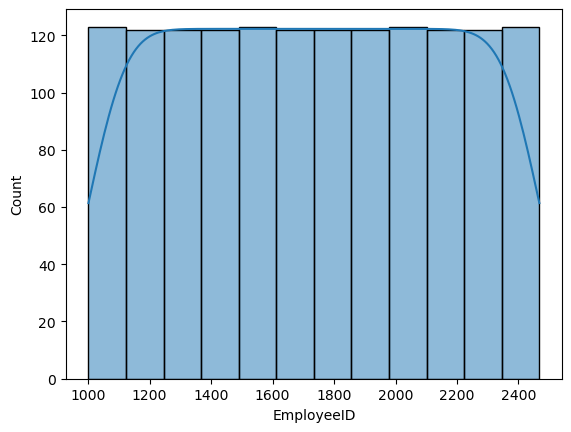

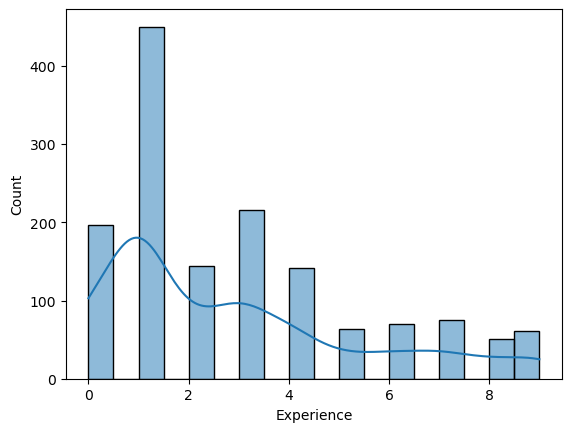

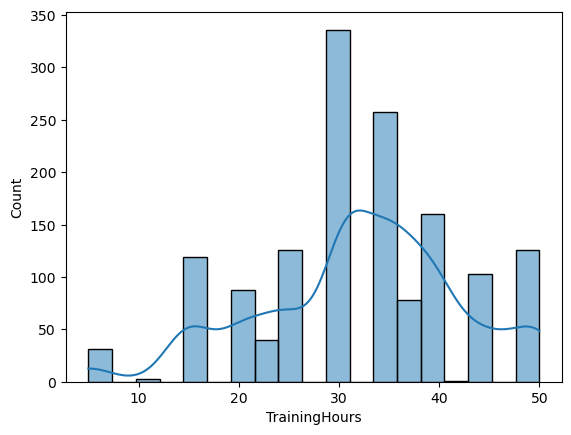

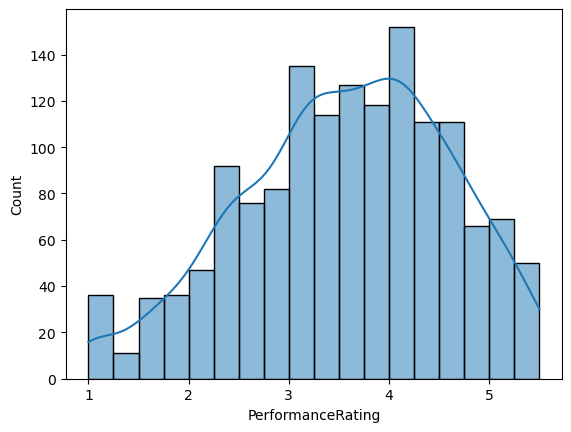

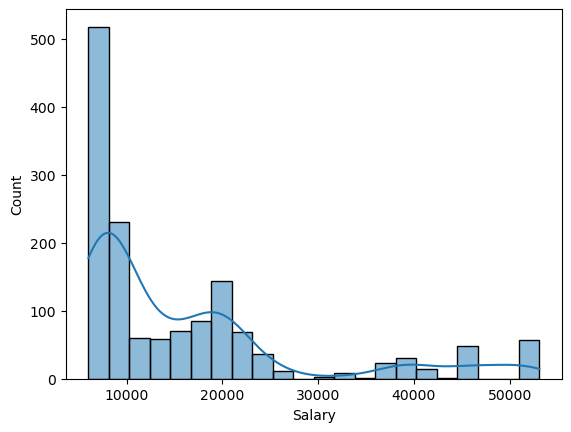

In [11]:
for column in numerical_col:
    sns.histplot(data=df[column],kde=True)
    plt.show()

In [12]:
for column in categorical_col:
    print(df[column].value_counts())
    fig=px.pie(df[column].value_counts(),
               names=df[column].value_counts().index,
               values=df[column].value_counts().values,
               title=f'{column} Distribution ')
    fig.show()


Department
IT           720
Sales        445
Marketing    240
HR            63
Name: count, dtype: int64


Gender
Male      883
Female    585
Name: count, dtype: int64


Experience_category
Entry-level    647
Junior         501
Mid-level      208
Senior         112
Name: count, dtype: int64


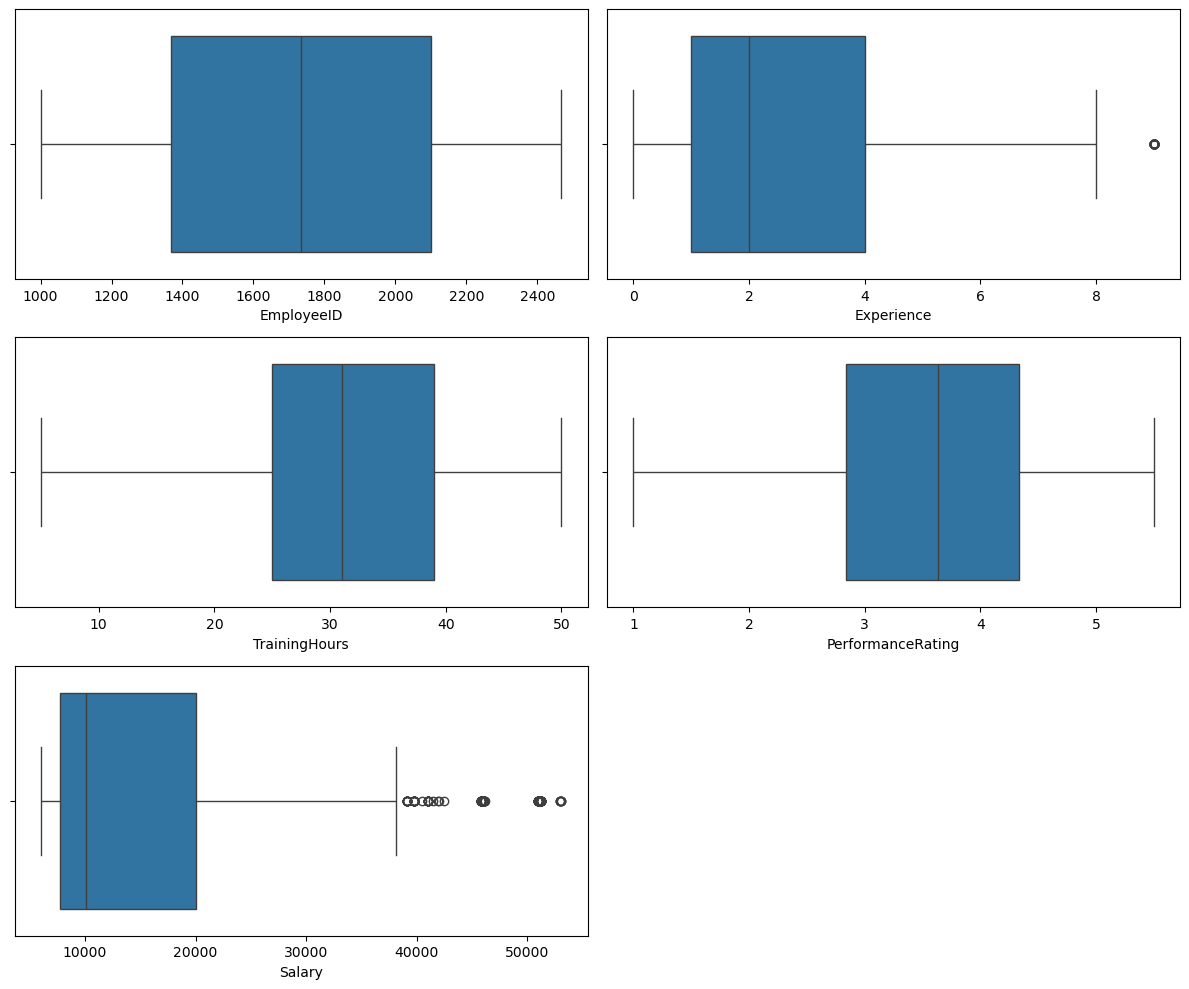

In [13]:
fig,axes=plt.subplots(3,2,figsize=(12,10))
axes=axes.flatten()
for i,col in enumerate(numerical_col):
    sns.boxplot(x=df[col],ax=axes[i])
for j in range(len(numerical_col),len(axes)):
    axes[j].axis('off')
plt.tight_layout()
plt.show()

`Skewness calculation`

In [14]:
skew_df=df[numerical_col].skew().reset_index()
skew_df.columns=['Attribute','Skewness']
skew_df['Distribution']=skew_df['Skewness'].apply(lambda x: 'Symmetric' if abs(x) <= 0.5 else 'Skewed' )
skew_df['Skewness']=skew_df["Skewness"].round(2)
print(skew_df)

           Attribute  Skewness Distribution
0         EmployeeID      0.00    Symmetric
1         Experience      0.95       Skewed
2      TrainingHours     -0.38    Symmetric
3  PerformanceRating     -0.31    Symmetric
4             Salary      1.63       Skewed


`identify outliers`

In [15]:
outlier_variables=[]
print(numerical_col)

#IQR method
for column in numerical_col:
    Q1=df[column].quantile(0.25)
    Q3=df[column].quantile(0.75)
    IQR=Q3-Q1
    lower_bound = Q1-1.5*IQR
    upper_bound = Q3+1.5*IQR
    mask[column]=(df[column]<lower_bound)|(df[column]>upper_bound)
    count_outlier = mask[column].sum()
    print(count_outlier)
    if count_outlier>0:
        outlier_variables.append(column)  
print(outlier_variables,'\n')



['EmployeeID', 'Experience', 'TrainingHours', 'PerformanceRating', 'Salary']


NameError: name 'mask' is not defined

In [ ]:
print((df.index[mask['Experience']]))

Index([  48,  281,  616,  829,  833,  834,  843,  846,  848,  851,
       ...
       1412, 1420, 1421, 1434, 1435, 1438, 1452, 1453, 1460, 1462],
      dtype='int64', length=152)


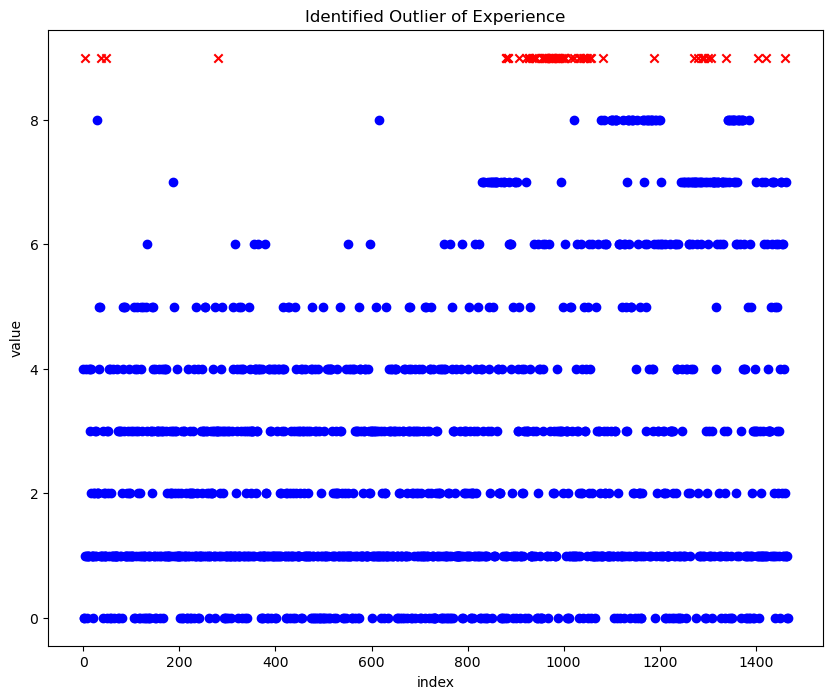

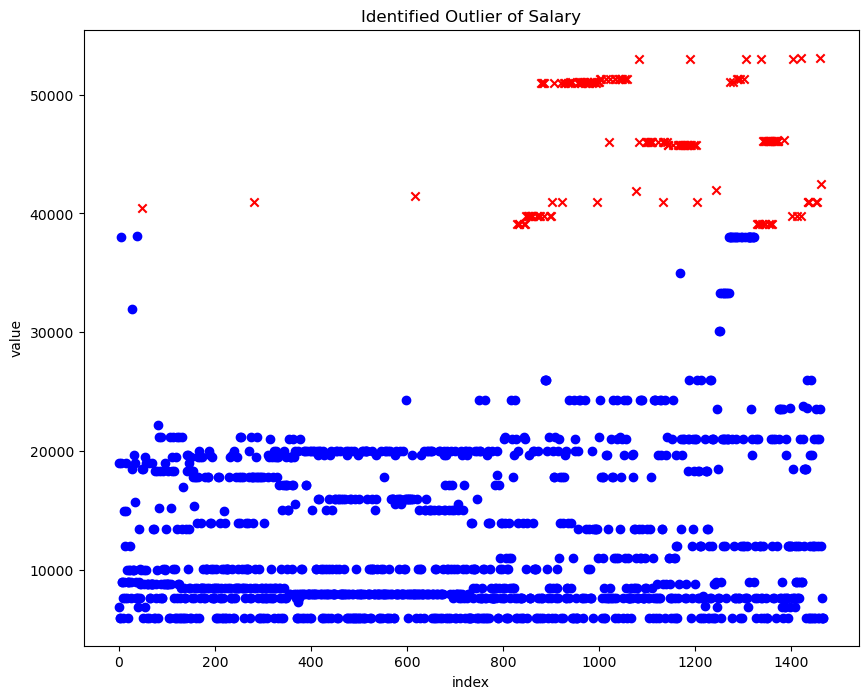

In [ ]:
for col in outlier_variables:
    plt.figure(figsize=(10,8))
    plt.scatter(df.index[mask[col]],df[col][mask[col]],
    marker='x',label='Outlier',color='red')
    plt.scatter(df.index[~mask[col]],df[col][~mask[col]],
    marker='o',label='Non-Outliers',color='blue')
    plt.xlabel("index")
    plt.ylabel("value")
    plt.title(f"Identified Outlier of {col}")
    plt.show()